#### Superstore Sales Analysis
Dataset from Kaggle. Contains sales, profit, and customer data for a fictional US retail store (2014–2017).

#### About This Analysis

**Tools used:** Python (pandas, matplotlib, seaborn, plotly express)

**Steps taken:**

1. Loaded and inspected the dataset
2. Fixed data types: converted Order Date and Ship Date from string to datetime, Postal Code from integer to string (it's an identifier, not a number)
3. Quality checks: confirmed zero nulls, zero duplicate rows, no placeholder values
4. Dropped ID columns (Row ID, Order ID, Customer ID, Product ID) without any analytical value
5. Univariate analysis: explored distributions of categorical and numeric columns. Used value counts, summary stats, and bar charts
6. Bivariate analysis: grouped metrics by time (Year, Month, Year-Month) to identify trends. Also explored profit and sales by Sub-Category, Category, and Region
7. Multivariate analysis: combined time and category dimensions to see how Sales and Profit behave month by month across different product categories and years

I learned that Technology is the store's most profitable category despite being the least ordered; and copiers are the most profitable sub-category. Office supplies are the most purchased category in volume.

In [78]:
#import the needed libraries

import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

#### 2. Load the Data

In [80]:
# Read the CSV file and store it in a DataFrame variable
df = pd.read_csv('Sample - Superstore.csv', encoding='utf-8', encoding_errors='ignore')

pd.set_option('display.max_columns', None)

# Display the first 5 rows of the DataFrame
df.head()

#We are observing 9994 transactions by customers. Example in row 1 and 2, Claire Gute bought 2 Bookcases for $261.96 total (so ~$131 each), with no discount, making $41.91 profit for the store.
#she also bought 3 Chairs for $731.94 total (~$244 each), again no discount, making $219.58 profit for the store
# Both rows share the same Order ID (CA-2016-152156), which confirms they're from one single order

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#### 3. Inspect & Clean

In [82]:
df.info()
#dataset has 9994 rows and 21 columns
#no indication of nulls
#ship date, order date are objects-they should be date format
#postal code should be object format. It is an identifier, not a number. We'd never do math on it.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [83]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Postal Code']=df['Postal Code'].apply(str)

# fixed. dates are now datetime, postal code is now a string.

#### 4. Quality Checks

In [85]:
df.isnull().sum()
#no nulls exist

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [86]:
#Identifying anomalies #Check the number of rows containing * and # values
rows_chars = df[df.isin(['*', '#']).any(axis=1)]
print(f"Number of rows: {len(rows_chars)}")
#there are no such special characters in the dataset

#checking duplicates
duplicated_rows=df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicated_rows)}")
#there are no duplicates in this data frame. 

Number of rows: 0
Number of duplicate rows: 0


In [87]:
# Drop all ID columns; not needed for analysis
id_cols = ['Row ID', 'Order ID', 'Customer ID', 'Product ID']
df = df.drop(columns=id_cols)

print('Remaining columns:', df.columns.tolist())
print('Shape:', df.shape)
# down to 17 columns.

Remaining columns: ['Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Shape: (9994, 17)


In [88]:
df[['Sales','Quantity','Discount','Profit']].describe()

# Display summary statistics for numeric columns in the DataFrame

#AVG Sales is $230/229.86
#Half of all purchases are $54.49 or less (median)
#The average is $229, but the max hits $22,638. A small number of very large orders are pulling the mean way up, which is why mean ($230) and median ($54) are so far apart. This is a right skew.
#75% of purchases are under $210, but the top 25% can go all the way to $22,638

#Quantity
#Most orders are small: 50% order 3 units or fewer, 75% of orders are 5 or fewer. Max ordered items is 14, and average is around 4. 

# Profit: ranges from -$6,600 to +$8,400. negative profit exists meaning some orders are losing money.
# Discount: median is 0.20. a quarter/25% of all orders have zero discount.


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


#### 5. Univariate Analysis : Categorical Columns

In [90]:
# Frequency count
#df['Segment'].value_counts() and df['Ship Mode'].value_counts() etc will be put in a loop to show value counts for each categorical column

relevant_cols = [
 'Ship Mode', 'Customer Name',
    'Segment', 'Country', 'City', 'State',
    'Region', 'Category', 'Sub-Category', 'Product Name'
]
for col in relevant_cols:
    print(f"\n")
    print(df[col].value_counts())

# Country only has 1 unique value (US only) 
# City (531 values), customer name has 793 and Product Name (1,850) are too granular for most groupbys.



Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


Customer Name
William Brown          37
John Lee               34
Matt Abelman           34
Paul Prost             34
Chloris Kastensmidt    32
                       ..
Lela Donovan            1
Anthony O'Donnell       1
Carl Jackson            1
Ricardo Emerson         1
Jocasta Rupert          1
Name: count, Length: 793, dtype: int64


Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


Country
United States    9994
Name: count, dtype: int64


City
New York City      915
Los Angeles        747
Philadelphia       537
San Francisco      510
Seattle            428
                  ... 
Glenview             1
Missouri City        1
Rochester Hills      1
Palatine             1
Manhattan            1
Name: count, Length: 531, dtype: int64


State
California              2001
New York                1128
Texas     

In [91]:
# Count unique values for each relevant column
relevant_cols = [
 'Ship Mode', 'Customer Name',
    'Segment', 'Country', 'City', 'State',
    'Region', 'Category', 'Sub-Category', 'Product Name'
]

for col in relevant_cols:
    print(f"{col:<20} {df[col].nunique():>6} unique values")

# Best dimensions to use: Segment (3), Region (4), Category (3), Sub-Category (17), Ship Mode (4).

Ship Mode                 4 unique values
Customer Name           793 unique values
Segment                   3 unique values
Country                   1 unique values
City                    531 unique values
State                    49 unique values
Region                    4 unique values
Category                  3 unique values
Sub-Category             17 unique values
Product Name           1850 unique values


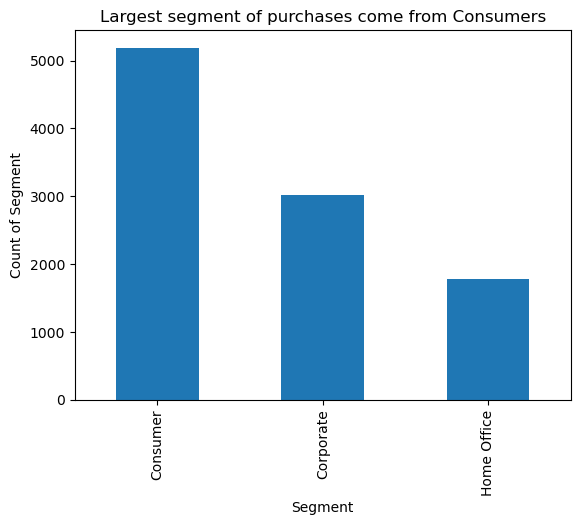

In [92]:
df['Segment'].value_counts().plot(kind='bar')
plt. title('Largest segment of purchases come from Consumers')
plt.xlabel('Segment')
plt.ylabel('Count of Segment')
plt.show()

#Our biggest buyers are the consumer segment.

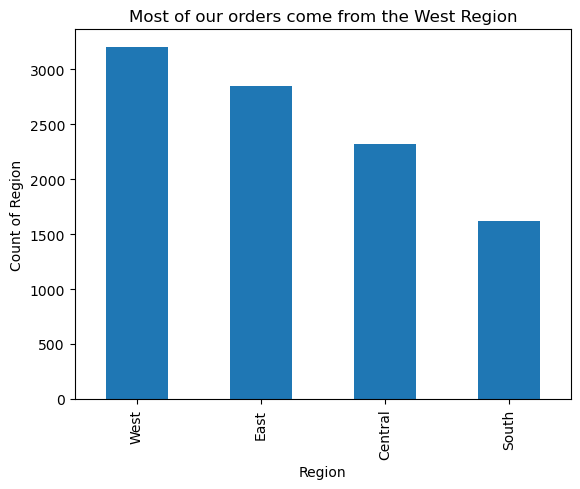

In [93]:
df['Region'].value_counts().plot(kind='bar')
plt. title('Most of our orders come from the West Region')
plt.xlabel('Region')
plt.ylabel('Count of Region')
plt.show()

#our largest markets are the West and East. Our smallest market is the South.

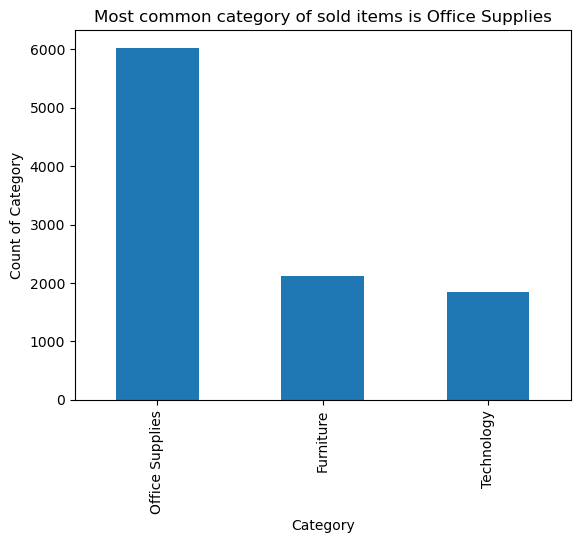

In [94]:
df['Category'].value_counts().plot(kind='bar')
plt. title('Most common category of sold items is Office Supplies')
plt.xlabel('Category')
plt.ylabel('Count of Category')
plt.show()

#Most common category of sold items is Office Supplies (note that volume does not mean profit)
# we'll see in the bivariate analysis section that Technology is the most profitable category

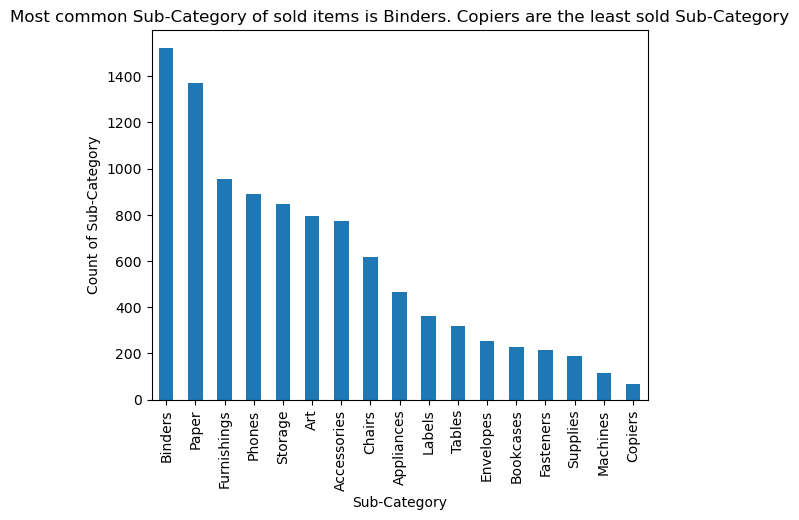

In [95]:
df['Sub-Category'].value_counts().plot(kind='bar')
plt. title('Most common Sub-Category of sold items is Binders. Copiers are the least sold Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Count of Sub-Category')
plt.show()
#Most common Sub-Category of sold items is Binders. Copiers are the least sold Sub-Category.
# we see later that despite copiers being least sold in volume, they are the most profitable sub-category

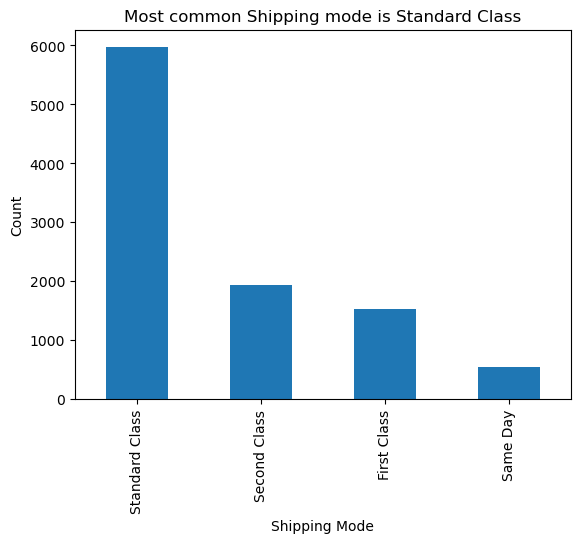

In [96]:
df['Ship Mode'].value_counts().plot(kind='bar')
plt. title('Most common Shipping mode is Standard Class')
plt.xlabel('Shipping Mode')
plt.ylabel('Count')
plt.show()

#same day shipping is rarely chosen (likely premium and expensive)

In [97]:
# a year and month column to work with
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df.groupby('Year')['Sales'].sum()

# revenue grew every year from 484247 in 2014/2015 to 733215 in 2017
# revenue did dip slightly in 2015 before picking up again in 2016

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [98]:
df.groupby('Year')['Profit'].sum()
#Profits have also grown every year. However the profit margin btn 2016 and 2017 have grown by less/dipped compared to the previous years

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

In [99]:
df.groupby('Year')['Discount'].mean()
#average discount is fairly flat across all years

Year
2014    0.158284
2015    0.155609
2016    0.154743
2017    0.156467
Name: Discount, dtype: float64

In [100]:
df.groupby('Year')['Quantity'].sum()
# units sold grew every year in line with revenue. 

Year
2014     7581
2015     7979
2016     9837
2017    12476
Name: Quantity, dtype: int64

In [101]:
df['Quantity'].value_counts().sort_index()
#most customers order btn 2–5 units

Quantity
1      899
2     2402
3     2409
4     1191
5     1230
6      572
7      606
8      257
9      258
10      57
11      34
12      23
13      27
14      29
Name: count, dtype: int64

In [102]:
df['Discount'].value_counts().sort_index()
#most common discounts are 0% and 20%

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

## Bivariate Analysis

In [104]:
df['Year-Month'] = df['Order Date'].dt.to_period('M')

df.groupby('Year-Month')['Sales'].sum()

#We see the trend of sales month by month over the years.
#sales are consistently slow in February across the years

Year-Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


In [105]:
df.groupby('Year-Month')['Profit'].sum()
#we see the trend of profit month by month over the years. Profit follows the same seasonal pattern as sales.

Year-Month
2014-01     2450.1907
2014-02      862.3084
2014-03      498.7299
2014-04     3488.8352
2014-05     2738.7096
2014-06     4976.5244
2014-07     -841.4826
2014-08     5318.1050
2014-09     8328.0994
2014-10     3448.2573
2014-11     9292.1269
2014-12     8983.5699
2015-01    -3281.0070
2015-02     2813.8508
2015-03     9732.0978
2015-04     4187.4962
2015-05     4667.8690
2015-06     3335.5572
2015-07     3288.6483
2015-08     5355.8084
2015-09     8209.1627
2015-10     2817.3660
2015-11    12474.7884
2015-12     8016.9659
2016-01     2824.8233
2016-02     5004.5795
2016-03     3611.9680
2016-04     2977.8149
2016-05     8662.1464
2016-06     4750.3781
2016-07     4432.8779
2016-08     2062.0693
2016-09     9328.6576
2016-10    16243.1425
2016-11     4011.4075
2016-12    17885.3093
2017-01     7140.4391
2017-02     1613.8720
2017-03    14751.8915
2017-04      933.2900
2017-05     6342.5828
2017-06     8223.3357
2017-07     6952.6212
2017-08     9040.9557
2017-09    10991.5556

In [106]:
df.groupby('Year-Month')['Quantity'].sum()
#we see the trend of quantity of items sold month by month over the years
#we sell highest quantities the months of September, November and December

Year-Month
2014-01     284
2014-02     159
2014-03     585
2014-04     536
2014-05     466
2014-06     521
2014-07     550
2014-08     609
2014-09    1000
2014-10     573
2014-11    1219
2014-12    1079
2015-01     236
2015-02     239
2015-03     515
2015-04     543
2015-05     575
2015-06     486
2015-07     557
2015-08     598
2015-09    1086
2015-10     631
2015-11    1310
2015-12    1203
2016-01     358
2016-02     306
2016-03     579
2016-04     635
2016-05     863
2016-06     742
2016-07     758
2016-08     693
2016-09    1316
2016-10     767
2016-11    1406
2016-12    1414
2017-01     597
2017-02     363
2017-03     885
2017-04     733
2017-05     887
2017-06     931
2017-07     840
2017-08     884
2017-09    1660
2017-10    1133
2017-11    1840
2017-12    1723
Freq: M, Name: Quantity, dtype: int64

/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



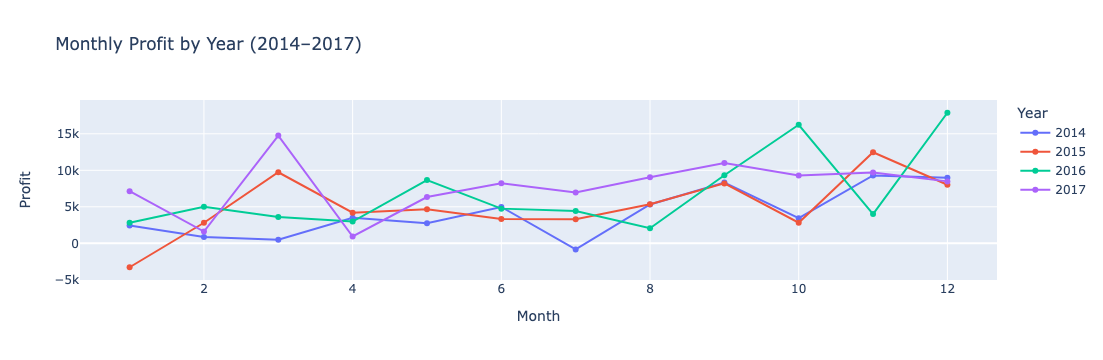

In [107]:
monthly = df.groupby(['Year', 'Month'])['Profit'].sum().reset_index()

fig = px.line(
    monthly,
    x='Month',
    y='Profit',
    color='Year',
    title='Monthly Profit by Year (2014–2017)',
    markers=True,
)
fig.show()

#In 2014, November had the highest profits
#In 2015, November had the highest profits
#In 2016, December had the highest profits
#In 2017, March had the highest profits. 
#March peak is unusual vs Nov/Dec in prior years and is worth investigating.


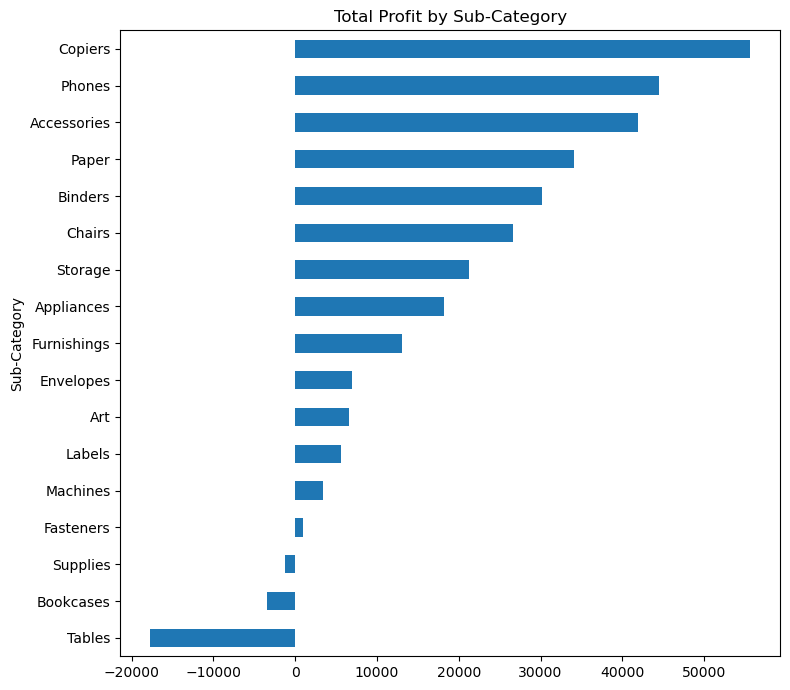

In [108]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sub_profit.plot(kind='barh', ax=ax)
ax.set_title('Total Profit by Sub-Category')
plt.tight_layout()
plt.show()
#copiers are the most profitable while tables, book cases, and supplies lose money/ loss makers

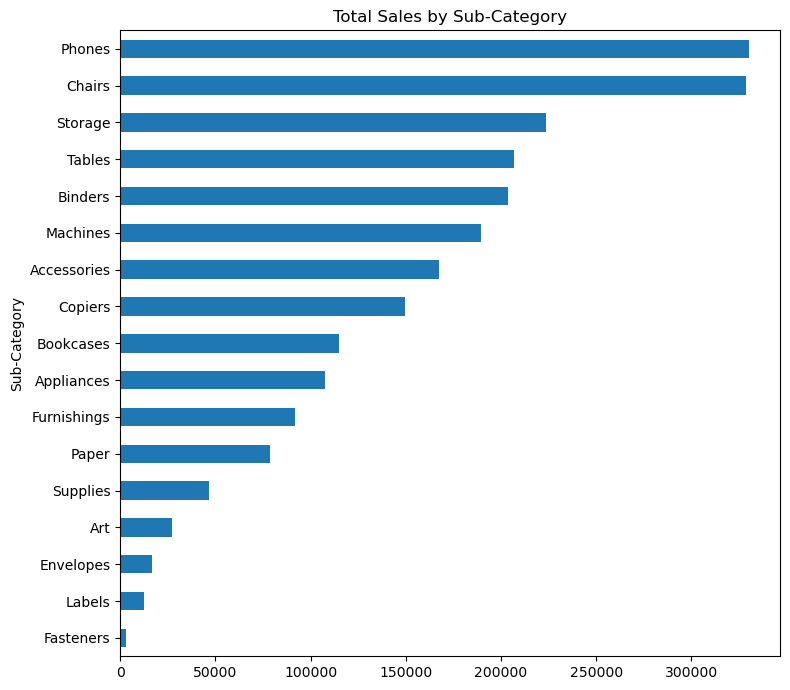

In [109]:
sub_profit = df.groupby('Sub-Category')['Sales'].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sub_profit.plot(kind='barh', ax=ax)
ax.set_title('Total Sales by Sub-Category')
plt.tight_layout()
plt.show()

#phones are the most sold item
#chairs are close behind.
# tables have decent sales but lose money

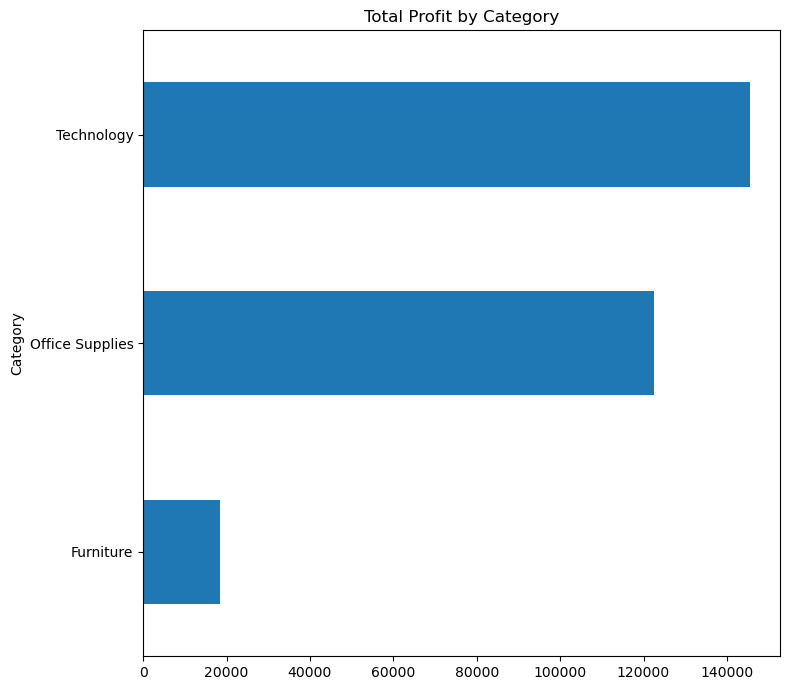

In [110]:
sub_profit = df.groupby('Category')['Profit'].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sub_profit.plot(kind='barh', ax=ax)
ax.set_title('Total Profit by Category')
plt.tight_layout()
plt.show()
# all three categories are profitable. Technology leads despite being 3rd in order volume.
# Office Supplies has the most orders, but not the highest profit per order.

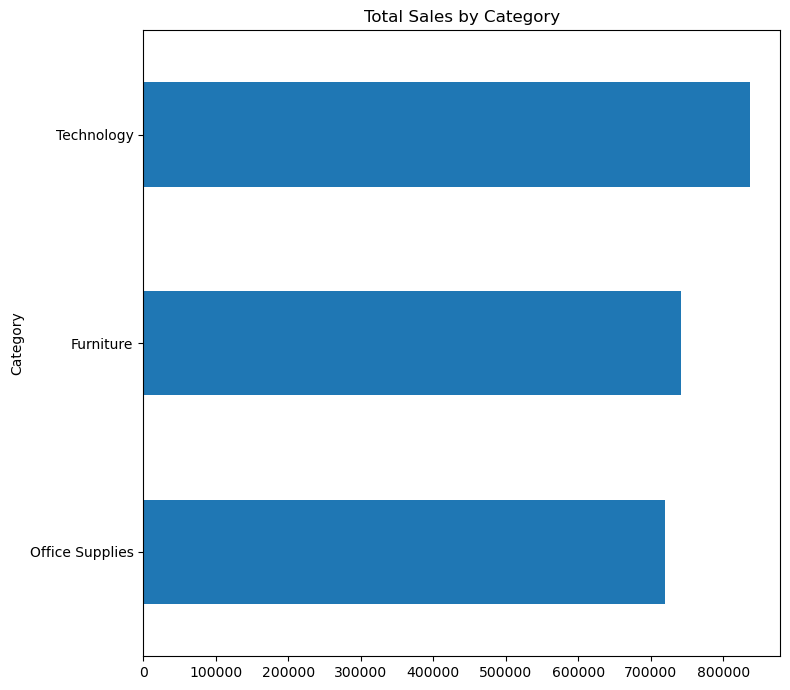

In [111]:
sub_profit = df.groupby('Category')['Sales'].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sub_profit.plot(kind='barh', ax=ax)
ax.set_title('Total Sales by Category')
plt.tight_layout()
plt.show()

#Technology leads on revenue despite being the least ordered category.
# Office Supplies has the most orders but the lowest revenue per order. They are cheap, high-volume items.

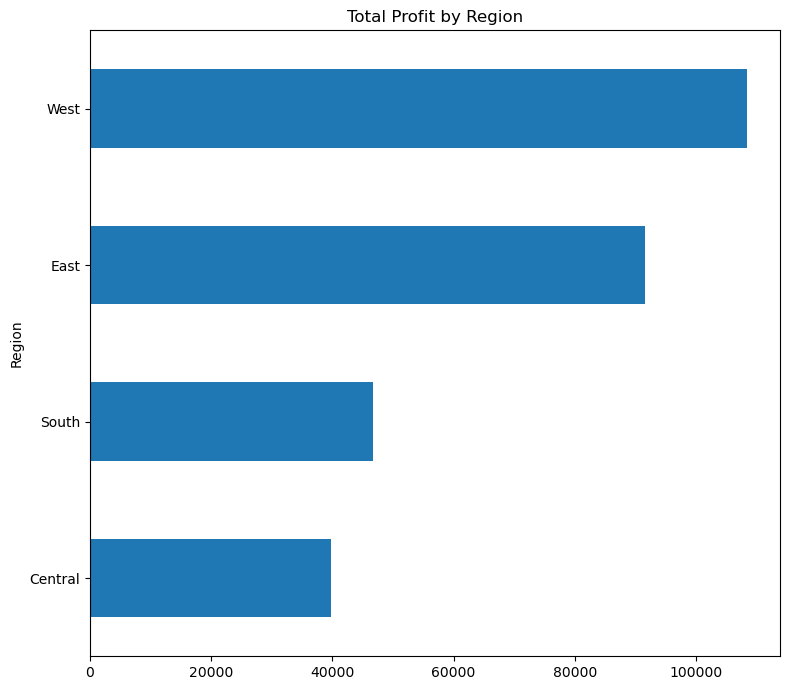

In [112]:
sub_profit = df.groupby('Region')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))

sub_profit.plot(kind='barh', ax=ax)
ax.set_title('Total Profit by Region')
plt.tight_layout()
plt.show()
## all four regions are profitable. Central has lowest profit despite being 3rd in order volume.
# West leads on both volume and profit. most efficient region.

<Axes: xlabel='Region'>

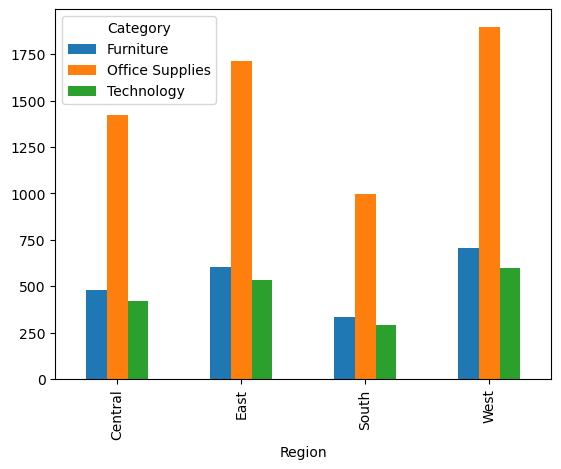

In [113]:
df2=df.groupby(['Region','Category']).size().unstack()

df2.plot(kind='bar')
# Office Supplies dominates in every region.
# Technology is consistently the lowest volume category everywhere.

<Axes: xlabel='Region'>

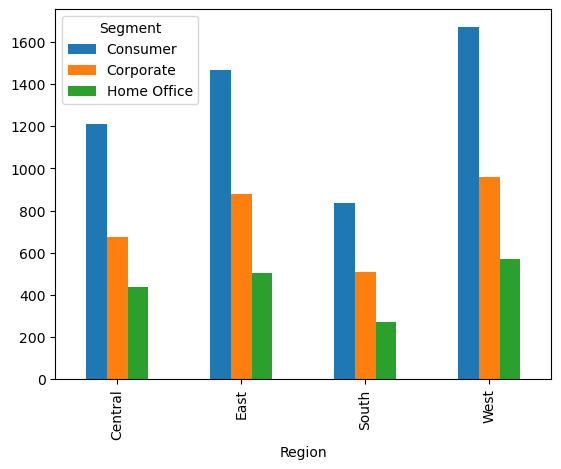

In [114]:
df2=df.groupby(['Region','Segment']).size().unstack()

df2.plot(kind='bar')
# Consumer segment leads in every region. The pattern is consistent across all regions.

<Axes: xlabel='Region'>

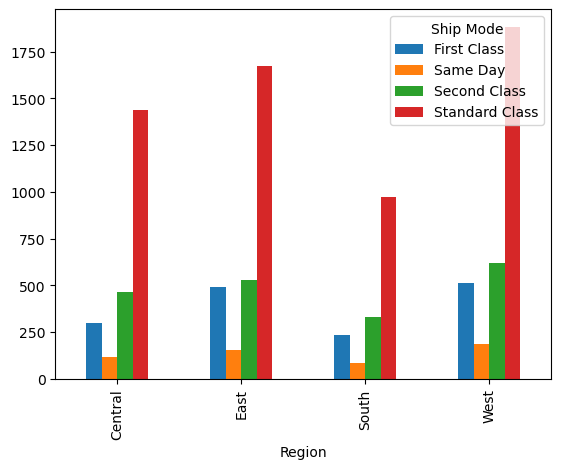

In [115]:
df2=df.groupby(['Region','Ship Mode']).size().unstack()

df2.plot(kind='bar')
# Standard Class dominates shipping in every region. 
# Same Day is minimal everywhere
# geography has no influence on how customers choose to ship.

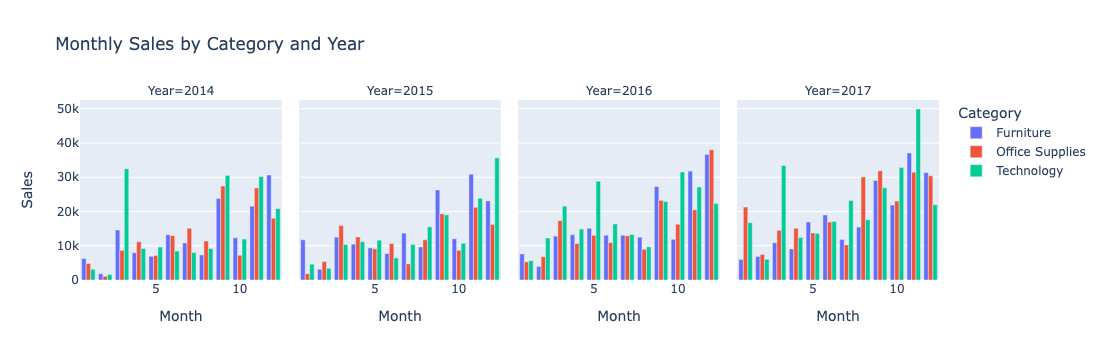

In [116]:
categories_bymonth = df.groupby(['Year', 'Month', 'Category'])['Sales'].sum().reset_index()

fig = px.bar(
    categories_bymonth,
    x='Month',
    y='Sales',
    color='Category',
    facet_col='Year',
    title='Monthly Sales by Category and Year',
    barmode='group',
)
fig.show()
#we see a consistent spike in sales every september and November/Q4

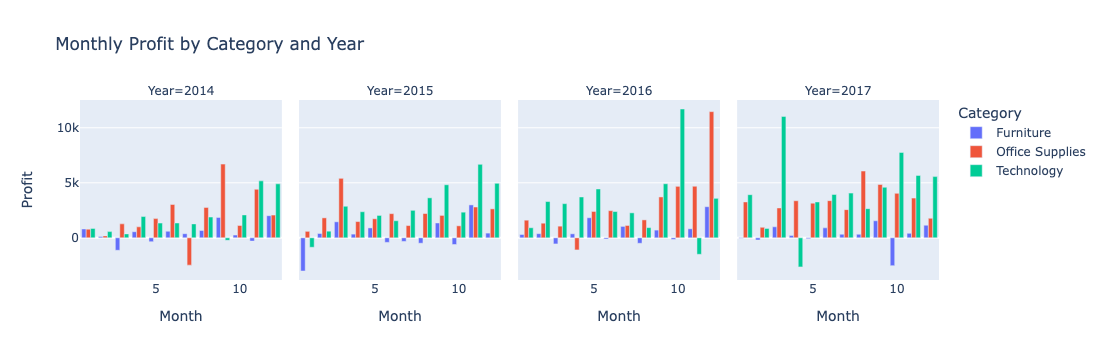

In [117]:
categories_bymonth = df.groupby(['Year', 'Month', 'Category'])['Profit'].sum().reset_index()

fig = px.bar(
    categories_bymonth,
    x='Month',
    y='Profit',
    color='Category',
    facet_col='Year',
    title='Monthly Profit by Category and Year',
    barmode='group',
)
fig.show()

#Technology leads profit every year in Q4